In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import add_region_column


In [2]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_tilt_vert_checked.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_eddies


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q22,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.189040,118.032741,47.992205,1.434563,74.597458,38,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
1,1,1463,CE,160.982386,-29.745743,260,274,920.121471,1352.093925,-0.000014,...,1.122134,115.905401,50.858737,1.417135,76.449111,38,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,1.055228,113.778061,53.725269,1.413542,78.300764,38,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,0.871468,111.650721,56.591801,1.411879,69.625773,38,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,33.976810,184.917206
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,0.945071,115.925719,57.471319,1.597888,72.613632,38,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,30.067059,181.174121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125221,2929,10646,CE,153.739453,-37.488262,181,61,515.983450,302.961328,-0.000026,...,0.978558,61.312206,19.408106,1.110214,55.409919,28,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,0.752304,4.278123
125222,2929,10647,CE,153.687115,-37.523299,181,60,512.684226,297.695084,-0.000027,...,0.972594,61.305207,19.388829,1.037331,44.896186,28,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,1.165623,28.370419
125223,2929,10648,CE,153.699708,-37.537452,181,60,514.199660,296.590511,-0.000021,...,0.949624,61.298208,19.369553,1.055789,38.796956,28,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
125224,2929,10649,CE,153.682657,-37.451789,180,62,510.019363,305.068558,-0.000019,...,0.937880,64.546558,19.604126,1.070344,40.028670,28,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN


In [3]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [4]:
df_eddies = add_region_column(
    df_eddies,
    X_grid, Y_grid,
    lon_rho, lat_rho,
    h, mask_rho
)

# --------------------------------------------------
# Region grouping
# --------------------------------------------------
region_group_map = {
    'S1': 'Upstream',
    'U1': 'Upstream',
    'U2': 'Upstream',
    'S2': 'Downstream',
    'D1': 'Downstream',
    'D2': 'Downstream'
}

df_eddies['RegionGroup'] = df_eddies['Region'].map(region_group_map)

df_AE = df_eddies[df_eddies.Cyc=='AE'].copy().dropna()
df_CE = df_eddies[df_eddies.Cyc=='CE'].copy().dropna()


In [5]:
# df_TDis_ave = pd.DataFrame(columns=['Eddy', 'Cyc', 'ave_TDis', 'min_TDis', 'max_TDis'])
# for eddy in df_eddies.Eddy.unique():
#     df = df_eddies[df_eddies.Eddy==eddy].copy().dropna()
#     if len(df) >= 30:
#         df_TDis_ave.loc[len(df_TDis_ave)] = {'Eddy': eddy, 'Cyc': df.iloc[0].Cyc, 'ave_TDis': df.TiltDis.mean(),
#                                             'min_TDis': df.TiltDis.min(), 'max_TDis': df.TiltDis.max()}
# df_TDis_ave = df_TDis_ave.dropna()
# df_TDis_ave_AE = df_TDis_ave[df_TDis_ave.Cyc=='AE']
# df_TDis_ave_CE = df_TDis_ave[df_TDis_ave.Cyc=='CE']
# df_TDis_ave

df_TDis_ave = pd.DataFrame(
    columns=['Eddy', 'Cyc', 'RegionGroup', 'RegionFrac',
             'ave_TDis', 'min_TDis', 'max_TDis']
)

for eddy in df_eddies.Eddy.unique():

    df = df_eddies[df_eddies.Eddy == eddy].copy().dropna(
        subset=['TiltDis', 'RegionGroup']
    )

    if len(df) >= 30:

        frac = df['RegionGroup'].value_counts(normalize=True)
        dom_region = frac.index[0]
        dom_frac = frac.iloc[0]

        df_TDis_ave.loc[len(df_TDis_ave)] = {
            'Eddy': eddy,
            'Cyc': df.iloc[0].Cyc,
            'RegionGroup': dom_region,
            'RegionFrac': dom_frac,
            'ave_TDis': df.TiltDis.mean(),
            'min_TDis': df.TiltDis.min(),
            'max_TDis': df.TiltDis.max()
        }

df_TDis_ave = df_TDis_ave.dropna()

df_TDis_ave_AE = df_TDis_ave[df_TDis_ave.Cyc == 'AE']
df_TDis_ave_CE = df_TDis_ave[df_TDis_ave.Cyc == 'CE']


In [6]:
# def circular_mean_deg_true_north(deg):
#     deg = np.asarray(deg)
#     r = np.deg2rad(deg)
#     C = np.mean(np.cos(r))
#     S = np.mean(np.sin(r))
#     return np.rad2deg(np.arctan2(S, C)) % 360 

# df_TDir_ave = pd.DataFrame(columns=['Eddy', 'Cyc', 'ave_TDir'])
# for eddy in df_eddies.Eddy.unique():
#     df = df_eddies[df_eddies.Eddy==eddy].copy().dropna()
#     if len(df) >= 30:
#         df_TDir_ave.loc[len(df_TDir_ave)] = {'Eddy': eddy, 'Cyc': df.iloc[0].Cyc, 'ave_TDir': circular_mean_deg_true_north(df.TiltDir)}
# df_TDir_ave = df_TDir_ave.dropna()
# df_TDir_ave_AE = df_TDir_ave[df_TDir_ave.Cyc=='AE']
# df_TDir_ave_CE = df_TDir_ave[df_TDir_ave.Cyc=='CE']
# df_TDir_ave

def circular_mean_deg_true_north(deg):
    deg = np.asarray(deg)
    r = np.deg2rad(deg)

    C = np.mean(np.cos(r))
    S = np.mean(np.sin(r))

    return np.rad2deg(np.arctan2(S, C)) % 360


df_TDir_ave = pd.DataFrame(
    columns=[
        'Eddy',
        'Cyc',
        'RegionGroup',
        'RegionFrac',
        'ave_TDir'
    ]
)

for eddy in df_eddies.Eddy.unique():

    df = (
        df_eddies[df_eddies.Eddy == eddy]
        .copy()
        .dropna(subset=['TiltDir', 'RegionGroup'])
    )

    if len(df) >= 30:

        frac = df['RegionGroup'].value_counts(normalize=True)

        dom_region = frac.index[0]
        dom_frac = frac.iloc[0]

        df_TDir_ave.loc[len(df_TDir_ave)] = {
            'Eddy': eddy,
            'Cyc': df.iloc[0].Cyc,
            'RegionGroup': dom_region,
            'RegionFrac': dom_frac,
            'ave_TDir': circular_mean_deg_true_north(
                df.TiltDir
            )
        }

df_TDir_ave = df_TDir_ave.dropna()

# optional: only retain eddies spending >50% of lifetime
# in one of the two groups
# df_TDir_ave = df_TDir_ave[df_TDir_ave.RegionFrac > 0.5]

df_TDir_ave_AE = (
    df_TDir_ave[df_TDir_ave.Cyc == 'AE']
)

df_TDir_ave_CE = (
    df_TDir_ave[df_TDir_ave.Cyc == 'CE']
)

df_TDir_ave


,Eddy,Cyc,RegionGroup,RegionFrac,ave_TDir
0,1,CE,Upstream,1.00000,110.638405
1,2,CE,Upstream,1.00000,147.642512
2,3,AE,Upstream,1.00000,332.682184
3,4,AE,Upstream,1.00000,13.755621
4,5,AE,Downstream,0.79661,32.834825
...,...,...,...,...,...
1282,2921,CE,Downstream,1.00000,260.848927
1283,2923,CE,Downstream,1.00000,148.493604
1284,2924,CE,Upstream,1.00000,241.468316
1285,2925,AE,Downstream,1.00000,127.437273


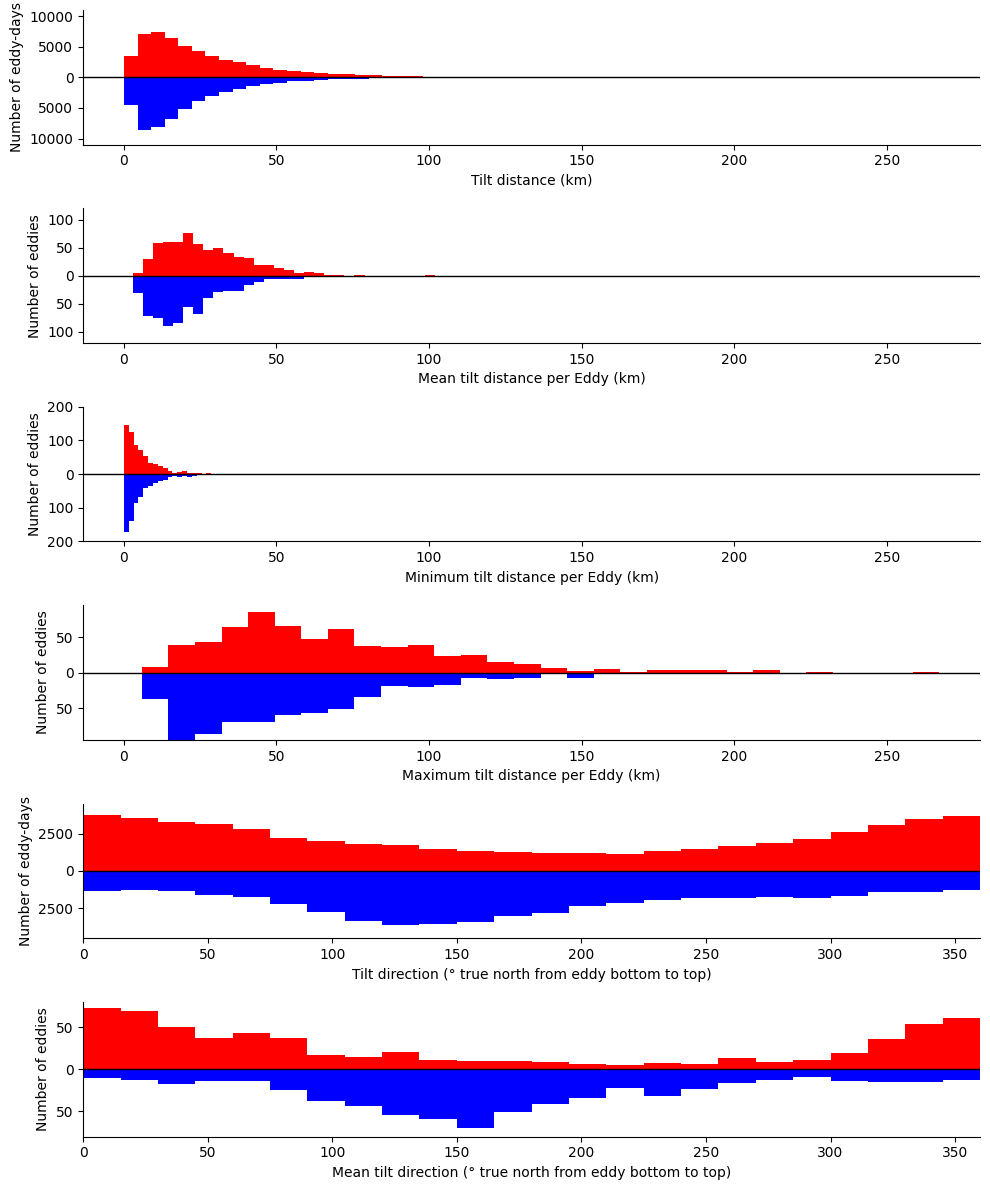

In [7]:
fig, axs = plt.subplots(6, 1, figsize=(10, 12))

def clean(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return a[np.isfinite(a)], b[np.isfinite(b)]

def shared_bins(a, b, method='fd', min_bins=12, max_bins=40):
    a, b = clean(a, b)
    all_vals = np.concatenate([a, b])
    edges = np.histogram_bin_edges(all_vals, bins=method)
    
    n_bins = len(edges) - 1
    if n_bins < min_bins:
        edges = np.linspace(all_vals.min(), all_vals.max(), min_bins + 1)
    elif n_bins > max_bins:
        edges = np.linspace(all_vals.min(), all_vals.max(), max_bins + 1)
    return edges

def mirrored_hist(ax, ae, ce, bins, xlabel, ylabel, ylim=None, xlim=None):
    ae, ce = clean(ae, ce)
    
    ax.hist(ae, bins=bins, color='r')
    counts, edges = np.histogram(ce, bins=bins)
    ax.bar(edges[:-1], -counts, width=np.diff(edges), color='b', align='edge')
    
    ax.axhline(0, color='k', linewidth=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([abs(int(t)) for t in ax.get_yticks()])
    
    if ylim is not None:
        ax.set_ylim(ylim)
    if xlim is not None:
        ax.set_xlim(xlim)

# --- Plot 0 ---
bins0 = shared_bins(df_AE.TiltDis, df_CE.TiltDis, method='fd', min_bins=20, max_bins=60)
mirrored_hist(
    axs[0],
    df_AE.TiltDis,
    df_CE.TiltDis,
    bins0,
    'Tilt distance (km)',
    'Number of eddy-days',
    ylim=(-11000, 11000)
)

# --- Plot 1 ---
bins1 = shared_bins(df_TDis_ave_AE.ave_TDis, df_TDis_ave_CE.ave_TDis, method='fd', min_bins=12, max_bins=30)
mirrored_hist(
    axs[1],
    df_TDis_ave_AE.ave_TDis,
    df_TDis_ave_CE.ave_TDis,
    bins1,
    'Mean tilt distance per Eddy (km)',
    'Number of eddies',
    ylim=(-120, 120),
    xlim=axs[0].get_xlim()
)

# --- Plot 2 ---
bins2 = shared_bins(df_TDis_ave_AE.min_TDis, df_TDis_ave_CE.min_TDis, method='fd', min_bins=12, max_bins=30)
mirrored_hist(
    axs[2],
    df_TDis_ave_AE.min_TDis,
    df_TDis_ave_CE.min_TDis,
    bins2,
    'Minimum tilt distance per Eddy (km)',
    'Number of eddies',
    ylim=(-200, 200),
    xlim=axs[0].get_xlim()
)

# --- Plot 3 ---
bins3 = shared_bins(df_TDis_ave_AE.max_TDis, df_TDis_ave_CE.max_TDis, method='fd', min_bins=12, max_bins=30)
mirrored_hist(
    axs[3],
    df_TDis_ave_AE.max_TDis,
    df_TDis_ave_CE.max_TDis,
    bins3,
    'Maximum tilt distance per Eddy (km)',
    'Number of eddies',
    ylim=(-95, 95),
    xlim=axs[0].get_xlim()
)

# --- Plot 4 ---
# For direction, fixed bins are better than "optimised" bins because the variable is angular
bins4 = np.arange(0, 361, 15)
mirrored_hist(
    axs[4],
    df_AE.TiltDir % 360,
    df_CE.TiltDir % 360,
    bins4,
    'Tilt direction (° true north from eddy bottom to top)',
    'Number of eddy-days',
    ylim=(-4500, 4500),
    xlim=(0, 360)
)

# --- Plot 5 ---
bins5 = np.arange(0, 361, 15)
mirrored_hist(
    axs[5],
    df_TDir_ave_AE.ave_TDir % 360,
    df_TDir_ave_CE.ave_TDir % 360,
    bins5,
    'Mean tilt direction (° true north from eddy bottom to top)',
    'Number of eddies',
    ylim=(-80, 80),
    xlim=(0, 360)
)

plt.tight_layout()
plt.show()


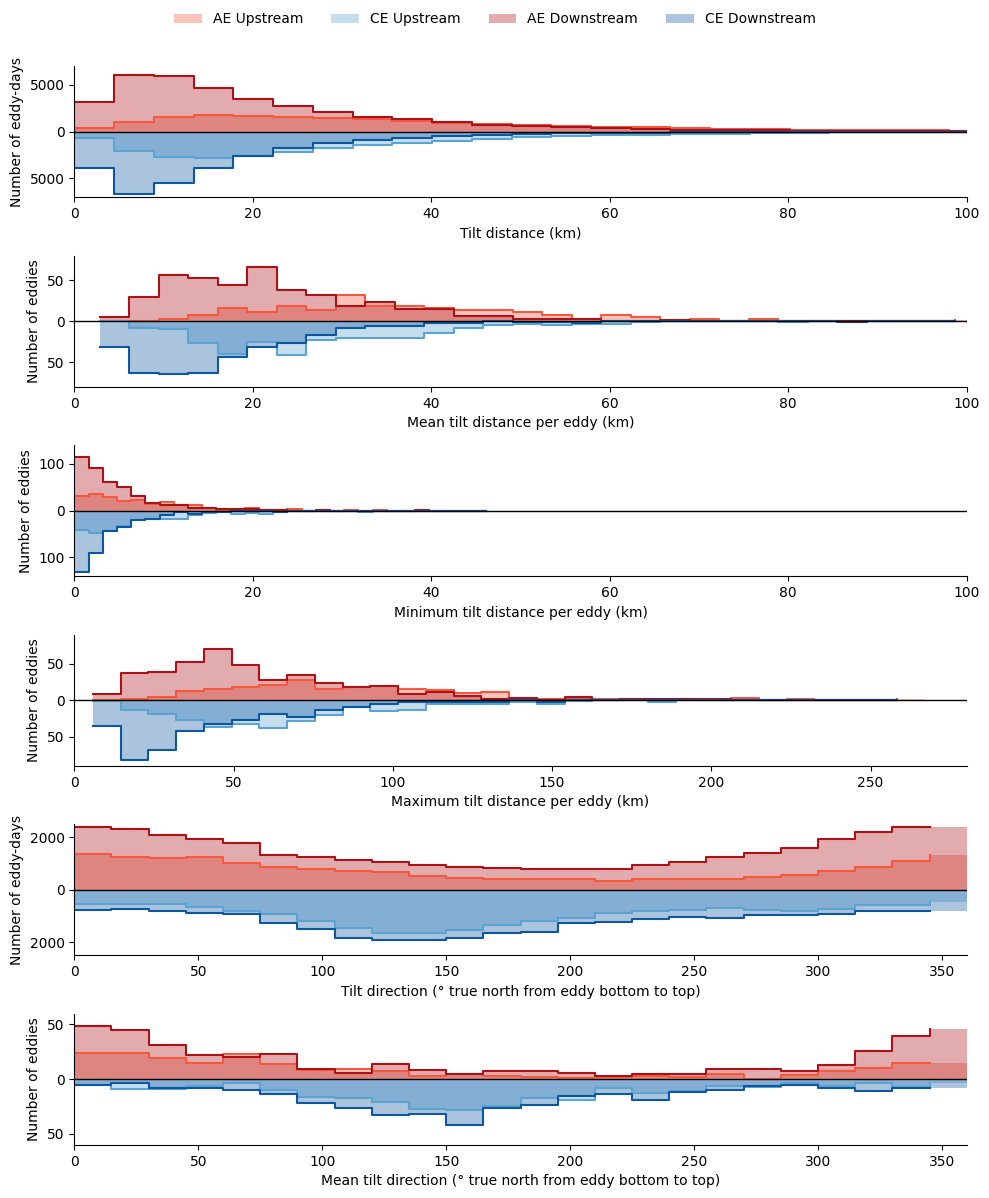

In [18]:
fig, axs = plt.subplots(6, 1, figsize=(10, 12))

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def clean1(a):
    a = np.asarray(a, dtype=float)
    return a[np.isfinite(a)]


def shared_bins_multi(vals, method='fd', min_bins=12, max_bins=40):
    vals = [clean1(v) for v in vals]
    vals = [v for v in vals if len(v) > 0]

    if len(vals) == 0:
        return np.linspace(0, 1, min_bins + 1)

    all_vals = np.concatenate(vals)

    if np.all(all_vals == all_vals[0]):
        return np.linspace(all_vals[0] - 0.5, all_vals[0] + 0.5, min_bins + 1)

    edges = np.histogram_bin_edges(all_vals, bins=method)

    n_bins = len(edges) - 1

    if n_bins < min_bins:
        edges = np.linspace(all_vals.min(), all_vals.max(), min_bins + 1)
    elif n_bins > max_bins:
        edges = np.linspace(all_vals.min(), all_vals.max(), max_bins + 1)

    return edges

# def mirrored_hist_updown(
#     ax,
#     df_ae,
#     df_ce,
#     col,
#     bins,
#     xlabel,
#     ylabel,
#     ylim=None,
#     xlim=None,
#     alpha=0.35,
#     median_flag=False
# ):
#     reds = plt.get_cmap('Reds')
#     blues = plt.get_cmap('Blues')

#     red_cols = {
#         'Upstream': reds(0.55),
#         'Downstream': reds(0.85)
#     }

#     blue_cols = {
#         'Upstream': blues(0.55),
#         'Downstream': blues(0.85)
#     }

#     for region in ['Upstream', 'Downstream']:

#         ae = clean1(
#             df_ae.loc[df_ae.RegionGroup == region, col]
#         )

#         ce = clean1(
#             df_ce.loc[df_ce.RegionGroup == region, col]
#         )

#         # AE positive
#         ax.hist(
#             ae,
#             bins=bins,
#             color=red_cols[region],
#             alpha=alpha,
#             histtype='stepfilled',
#             label=f'AE {region}'
#         )

#         ae_counts, edges = np.histogram(ae, bins=bins)
#         ax.step(
#             edges[:-1],
#             ae_counts,
#             where='post',
#             color=red_cols[region],
#             linewidth=1.5
#         )

#         # CE negative
#         ce_counts, edges = np.histogram(ce, bins=bins)
#         ax.bar(
#             edges[:-1],
#             -ce_counts,
#             width=np.diff(edges),
#             color=blue_cols[region],
#             alpha=alpha,
#             align='edge',
#             label=f'CE {region}'
#         )

#         ax.step(
#             edges[:-1],
#             -ce_counts,
#             where='post',
#             color=blue_cols[region],
#             linewidth=1.5
#         )

#         if median_flag:
#             ls = '--' if region == 'Upstream' else '-'

#             if len(ae):
#                 ax.axvline(
#                     np.nanmedian(ae),
#                     color=red_cols[region],
#                     linestyle=ls,
#                     linewidth=2.5,
#                     zorder=100
#                 )

#             if len(ce):
#                 ax.axvline(
#                     np.nanmedian(ce),
#                     color=blue_cols[region],
#                     linestyle=ls,
#                     linewidth=2.5,
#                     zorder=100
#                 )

#     ax.axhline(0, color='k', linewidth=1)

#     ax.set_xlabel(xlabel)
#     ax.set_ylabel(ylabel)

#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)

#     ax.set_yticks(ax.get_yticks())
#     ax.set_yticklabels([abs(int(t)) for t in ax.get_yticks()])

#     if ylim is not None:
#         ax.set_ylim(ylim)

#     if xlim is not None:
#         ax.set_xlim(xlim)

def mirrored_hist_updown(
    ax, df_ae, df_ce, col, bins, xlabel, ylabel,
    ylim=None, xlim=None, alpha=0.35, median_flag=False,
    overflow_at=None
):
    reds = plt.get_cmap('Reds')
    blues = plt.get_cmap('Blues')

    red_cols = {'Upstream': reds(0.55), 'Downstream': reds(0.85)}
    blue_cols = {'Upstream': blues(0.55), 'Downstream': blues(0.85)}

    if overflow_at is not None:
        bins = bins[bins < overflow_at]
        bins = np.r_[bins, overflow_at]

    for region in ['Upstream', 'Downstream']:

        ae = clean1(df_ae.loc[df_ae.RegionGroup == region, col])
        ce = clean1(df_ce.loc[df_ce.RegionGroup == region, col])

        if overflow_at is not None:
            ae_plot = np.minimum(ae, overflow_at)
            ce_plot = np.minimum(ce, overflow_at)
        else:
            ae_plot = ae
            ce_plot = ce

        # AE positive
        ae_counts, edges = np.histogram(ae_plot, bins=bins)

        ax.bar(
            edges[:-1],
            ae_counts,
            width=np.diff(edges),
            color=red_cols[region],
            alpha=alpha,
            align='edge',
            label=f'AE {region}'
        )

        ax.step(
            edges[:-1],
            ae_counts,
            where='post',
            color=red_cols[region],
            linewidth=1.5
        )

        # CE negative
        ce_counts, edges = np.histogram(ce_plot, bins=bins)

        ax.bar(
            edges[:-1],
            -ce_counts,
            width=np.diff(edges),
            color=blue_cols[region],
            alpha=alpha,
            align='edge',
            label=f'CE {region}'
        )

        ax.step(
            edges[:-1],
            -ce_counts,
            where='post',
            color=blue_cols[region],
            linewidth=1.5
        )

        if median_flag:
            ls = '--' if region == 'Upstream' else '-'

            if len(ae):
                ax.axvline(np.nanmedian(ae), color=red_cols[region],
                           linestyle=ls, linewidth=2.5, zorder=100)

            if len(ce):
                ax.axvline(np.nanmedian(ce), color=blue_cols[region],
                           linestyle=ls, linewidth=2.5, zorder=100)

    ax.axhline(0, color='k', linewidth=1)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([abs(int(t)) for t in ax.get_yticks()])

    if overflow_at is not None:
        ax.set_xlim(0, overflow_at)
        xticks = list(ax.get_xticks())
        xticks = [t for t in xticks if t < overflow_at]
        xticks.append(overflow_at)
        ax.set_xticks(xticks)
        ax.set_xticklabels([
            f'>{int(overflow_at)}' if t == overflow_at else f'{int(t)}'
            for t in xticks
        ])

    elif xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

# --------------------------------------------------
# Plot 0: Tilt distance, eddy-days
# --------------------------------------------------

xmax = 100

bins0 = shared_bins_multi(
    [df_AE.TiltDis, df_CE.TiltDis],
    method='fd',
    min_bins=20,
    max_bins=60
)

mirrored_hist_updown(
    axs[0],
    df_AE,
    df_CE,
    'TiltDis',
    bins0,
    'Tilt distance (km)',
    'Number of eddy-days',
    xlim=(0, xmax),
    ylim=(-7000, 7000),
    median_flag=False,
    # overflow_at=overflow_at
)

# --------------------------------------------------
# Plot 1: Mean tilt distance per eddy
# --------------------------------------------------
bins1 = shared_bins_multi(
    [df_TDis_ave_AE.ave_TDis, df_TDis_ave_CE.ave_TDis],
    method='fd',
    min_bins=12,
    max_bins=30
)

mirrored_hist_updown(
    axs[1],
    df_TDis_ave_AE,
    df_TDis_ave_CE,
    'ave_TDis',
    bins1,
    'Mean tilt distance per eddy (km)',
    'Number of eddies',
    ylim=(-80, 80),
    xlim=axs[0].get_xlim(),
    median_flag=False,
    # overflow_at=overflow_at
)

# --------------------------------------------------
# Plot 2: Minimum tilt distance per eddy
# --------------------------------------------------
bins2 = shared_bins_multi(
    [df_TDis_ave_AE.min_TDis, df_TDis_ave_CE.min_TDis],
    method='fd',
    min_bins=12,
    max_bins=30
)

mirrored_hist_updown(
    axs[2],
    df_TDis_ave_AE,
    df_TDis_ave_CE,
    'min_TDis',
    bins2,
    'Minimum tilt distance per eddy (km)',
    'Number of eddies',
    ylim=(-140, 140),
    xlim=axs[0].get_xlim(),
    median_flag=False,
    # overflow_at=overflow_at
)

# --------------------------------------------------
# Plot 3: Maximum tilt distance per eddy
# --------------------------------------------------
bins3 = shared_bins_multi(
    [df_TDis_ave_AE.max_TDis, df_TDis_ave_CE.max_TDis],
    method='fd',
    min_bins=12,
    max_bins=30
)

mirrored_hist_updown(
    axs[3],
    df_TDis_ave_AE,
    df_TDis_ave_CE,
    'max_TDis',
    bins3,
    'Maximum tilt distance per eddy (km)',
    'Number of eddies',
    ylim=(-90, 90),
    xlim=(0, None), #axs[0].get_xlim(),
    median_flag=False,
    # overflow_at=overflow_at
)

# --------------------------------------------------
# Plot 4: Tilt direction, eddy-days
# --------------------------------------------------
bins4 = np.arange(0, 361, 15)

mirrored_hist_updown(
    axs[4],
    df_AE,
    df_CE,
    'TiltDir',
    bins4,
    'Tilt direction (° true north from eddy bottom to top)',
    'Number of eddy-days',
    ylim=(-2500, 2500),
    xlim=(0, 360),
    median_flag=False
)

# --------------------------------------------------
# Plot 5: Mean tilt direction per eddy
# --------------------------------------------------
bins5 = np.arange(0, 361, 15)

df_TDir_ave_AE = df_TDir_ave_AE.copy()
df_TDir_ave_CE = df_TDir_ave_CE.copy()

df_TDir_ave_AE['ave_TDir_mod'] = df_TDir_ave_AE['ave_TDir'] % 360
df_TDir_ave_CE['ave_TDir_mod'] = df_TDir_ave_CE['ave_TDir'] % 360

mirrored_hist_updown(
    axs[5],
    df_TDir_ave_AE,
    df_TDir_ave_CE,
    'ave_TDir_mod',
    bins5,
    'Mean tilt direction (° true north from eddy bottom to top)',
    'Number of eddies',
    ylim=(-60, 60),
    xlim=(0, 360),
    median_flag=False
)

# --------------------------------------------------
# Legend/display
# --------------------------------------------------
handles, labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=4,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
